In [181]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

ValueError: Could not interpret value `Transported` for `hue`. An entry with this name does not appear in `data`.

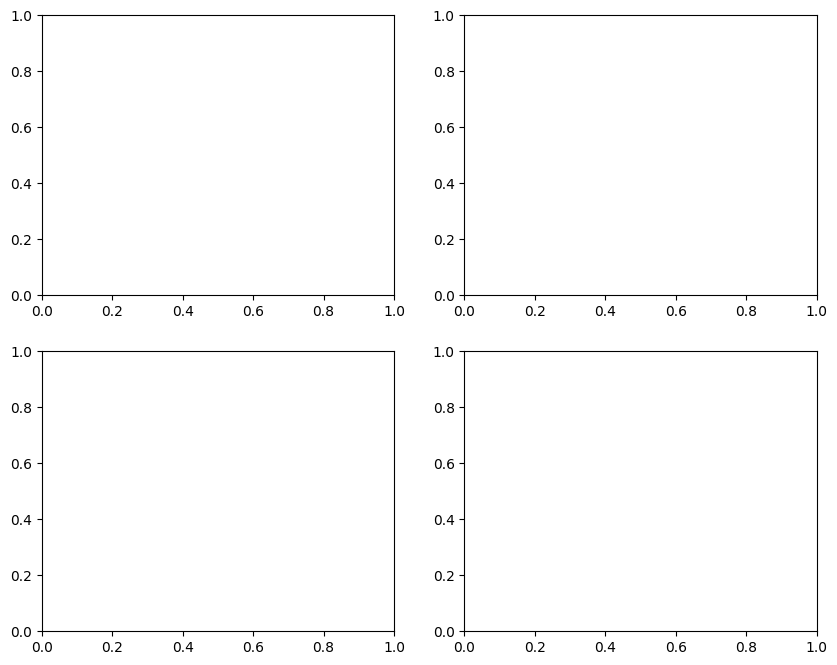

In [182]:
train_df = pd.read_csv("train.csv")
test_df = pd.read_csv("test.csv")

y = train_df['Transported']

train_df = train_df.drop('Transported', axis=1)

dataset_df = pd.concat([train_df, test_df], axis=0, sort=False)


fig, axes = plt.subplots(2, 2, figsize=(10, 8))

sns.countplot(data=dataset_df, x='CryoSleep', hue='Transported' , ax = axes[0][0])



spend_features = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']
dataset_df['Total_Spend'] = dataset_df[spend_features].sum(axis=1)

sns.histplot(
    data = dataset_df,
    x = 'Total_Spend',
    hue = 'Transported',
    bins = 50,
    multiple='stack',
    binrange = (0, 8000),
    ax = axes[0][1]
)

sns.histplot(
    data = dataset_df,
    x = 'Age',
    hue = 'Transported',
    bins = 50,
    multiple='stack',
    ax = axes[1][0]
)

sns.countplot(
    data = dataset_df,
    x = 'HomePlanet',
    hue = 'Transported',
    ax = axes[1][1]
)


plt.tight_layout()
plt.show()

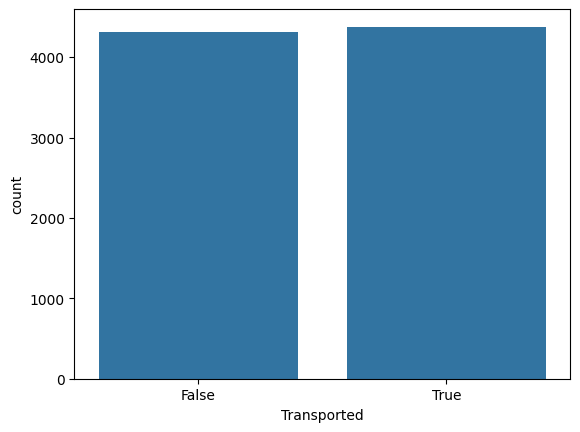

In [ ]:
sns.countplot(data = dataset_df , x = 'Transported')

plt.show()

In [ ]:
spending_cols = ['RoomService', 'FoodCourt', 'ShoppingMall', 'Spa', 'VRDeck']

for col in spend_features:
    condition1 = ((dataset_df['CryoSleep'] == True) & (dataset_df[col].isna()))
    dataset_df.loc[condition1 , col] = 0

    condition1 = ((dataset_df['CryoSleep'] == False) & (dataset_df[col].isna()))
    dataset_df.loc[condition1 , col] = dataset_df[col].median()

for col in spend_features:
    dataset_df[col] = dataset_df[col].fillna(dataset_df[col].median())


is_awake_by_spending = (dataset_df[spend_features] > 0).any(axis=1)
dataset_df.loc[is_awake_by_spending & dataset_df['CryoSleep'].isnull() , 'CryoSleep'] = False

dataset_df['CryoSleep'] = dataset_df['CryoSleep'].fillna(True)


dataset_df['Group'] = dataset_df['PassengerId'].apply(lambda x: x.split('_')[0])

mapHomePlanet = dataset_df.groupby('Group')['HomePlanet'].first().to_dict()
dataset_df['HomePlanet'] = dataset_df['HomePlanet'].fillna(dataset_df['Group'].map(mapHomePlanet))
dataset_df['HomePlanet'] = dataset_df['HomePlanet'].fillna(dataset_df['HomePlanet'].mode()[0])

dataset_df = dataset_df.drop(['Name'] , axis = 1)

dataset_df['Destination'] = dataset_df['Destination'].fillna(dataset_df['Destination'].mode()[0])
dataset_df['Age'] = dataset_df['Age'].fillna(dataset_df['Age'].median())

dataset_df['Cabin'] = dataset_df['Cabin'].fillna('U/U/U')

dataset_df['VIP'] = dataset_df['VIP'].fillna(False)

dataset_df.isna().sum().sort_values(ascending=False)


PassengerId     0
HomePlanet      0
CryoSleep       0
Cabin           0
Destination     0
Age             0
VIP             0
RoomService     0
FoodCourt       0
ShoppingMall    0
Spa             0
VRDeck          0
Transported     0
Total_Spend     0
Group           0
dtype: int64

In [ ]:
dataset_df['Total_Spend'] = dataset_df[spend_features].sum(axis=1)

dataset_df[['Deck', 'Num', 'Side']] = dataset_df['Cabin'].str.split('/', expand=True)
dataset_df.drop(columns=['Cabin'], inplace=True)

dataset_df['Num'] = dataset_df['Num'].replace('U', '-1').astype(int)

bool_cols = ['CryoSleep', 'VIP']
dataset_df[bool_cols] = dataset_df[bool_cols].astype(int)

categ_cols = ['HomePlanet', 'Destination', 'Deck', 'Side']
dataset_df = pd.get_dummies(dataset_df, columns=categ_cols, drop_first=True)
